# 💳 Referencia Académica — Clasificación: Aprobación de Créditos

**Materia:** Taller de Programación para el Análisis de Datos (TPAD) · FCE-UBA — TGAD  
**Temas:** Modelado · Sesgo y Varianza · Explicabilidad con SHAP · Equidad Algorítmica

---

> **Propósito:** Este notebook integra las consignas del ejercicio, el código de la solución docente,
> las interpretaciones esperadas y explicaciones teóricas ampliadas.
> Es una **guía de estudio y referencia metodológica** para entender el flujo completo
> de un proyecto de clasificación responsable.

## Esquema de cada sección

| Bloque | Descripción |
|--------|-------------|
| 📋 **Consigna** | Enunciado original del ejercicio |
| 📘 **Teoría** | Definiciones, fórmulas y contexto académico |
| 💻 **Código comentado** | Implementación con explicaciones línea a línea |
| 👨‍🏫 **Interpretación docente** | Respuestas esperadas por el profesor |
| 🔍 **Análisis propio** | Explicación ampliada y conexión con otros conceptos |

---
## Parte 0 — Setup y Dataset

In [1]:
# ── Importaciones ──────────────────────────────────────────────────────────
import numpy as np                        # operaciones numéricas y arrays
import pandas as pd                       # manipulación de DataFrames
import matplotlib.pyplot as plt           # gráficos base
import matplotlib
import seaborn as sns                     # gráficos estadísticos de alto nivel
import warnings
warnings.filterwarnings('ignore')         # suprimir warnings de versiones
matplotlib.rcParams['figure.dpi'] = 110  # resolución de figuras

# ── Modelos de clasificación ───────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ── Utilidades de modelado ─────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler  # normalización de features

np.random.seed(42)  # reproducibilidad global

---
### 📘 Teoría — El dataset sintético y el modelo logístico

Este ejercicio usa un **dataset generado artificialmente** con propiedades controladas.
Entender su construcción es clave para interpretar los resultados del análisis de equidad.

#### ¿Cómo se genera la variable `default`?

La probabilidad de default de cada solicitante se calcula con el **modelo logístico**:

$$P(\text{default}) = \sigma(\text{logit}) = \frac{1}{1 + e^{-\text{logit}}}$$

donde el logit se construye así:

$$\text{logit} = -0.022 \cdot (\text{historial} - 600) + 0.000014 \cdot \text{deuda} - 0.000006 \cdot \text{ingreso} - 0.30 \cdot \text{tipo\_empleo} + 0.008 \cdot \text{cuotas} + 0.5 + \text{genero\_bonus} + \varepsilon$$

#### Interpretación de cada término

| Término | Signo | Efecto sobre P(default) |
|---------|-------|------------------------|
| `historial_crediticio` | negativo | mejor historial → menos riesgo |
| `deuda_actual` | positivo | más deuda → más riesgo |
| `ingreso_mensual` | negativo | más ingreso → menos riesgo |
| `tipo_empleo` (dependiente=1) | negativo | empleo formal → menos riesgo |
| `cuotas` | positivo | más cuotas → más riesgo |
| `genero_bonus` | varía | **−1.0 para mujeres, 0.0 para hombres** |

#### El parámetro `genero_bonus = -1.0`

Un valor de −1 en el logit reduce significativamente la probabilidad de default.
Con la función sigmoide, pasar de `logit=0.5` a `logit=−0.5` equivale a bajar
P(default) de ≈0.62 a ≈0.38. Esto simula que **las mujeres son mejores pagadoras**,
un patrón documentado en datos reales de crédito.

#### El parámetro `ingreso_mu`

Los hombres tienen `ingreso_mu=88000` y las mujeres `ingreso_mu=60000`.
Esto simula la **brecha salarial de género** real. Esta diferencia introduce una
correlación entre género e ingreso que es central para el análisis de equidad:
el ingreso actúa como **variable proxy** del género — incluso un modelo que no
recibe `genero` explícitamente puede discriminar si usa `ingreso` como predictor.

In [2]:
# ── Función auxiliar: genera un bloque de observaciones para un género ──────
def bloque(rng, n_z, genero_label, ingreso_mu, genero_bonus):
    """Genera n_z filas para un grupo de género dado.

    rng           : generador de números aleatorios (numpy)
    n_z           : número de observaciones a generar
    genero_label  : 'M' o 'F'
    ingreso_mu    : media del ingreso mensual para este grupo
    genero_bonus  : término aditivo en el logit (−1.0 para mujeres, 0.0 para hombres)
    """
    # Features numéricas generadas con distribuciones realistas
    edad             = rng.integers(22, 65, n_z).astype(float)
    ingreso          = rng.normal(ingreso_mu, 15000, n_z).clip(8000, 250000)
    antiguedad_lab   = rng.uniform(0, 20, n_z).round(1)
    deuda_actual     = rng.normal(35000, 18000, n_z).clip(0, 150000)
    historial        = rng.normal(620, 70, n_z).clip(300, 850).round()
    monto_solicitado = rng.normal(55000, 20000, n_z).clip(5000, 200000)
    cuotas           = rng.integers(6, 61, n_z).astype(float)
    tipo_empleo      = rng.binomial(1, 0.6, n_z).astype(float)  # 60% en relación de dependencia
    genero           = np.array([genero_label] * n_z)

    # Cálculo del logit: combinación lineal de features con coeficientes fijos
    logit = (- 0.022*(historial-600)     # historial alto → menos riesgo
             + 0.000014*deuda_actual     # más deuda → más riesgo
             - 0.000006*ingreso          # más ingreso → menos riesgo
             - 0.30*tipo_empleo          # empleo formal → menos riesgo
             + 0.008*cuotas              # más cuotas → más riesgo
             + 0.5                       # intercepto base
             + genero_bonus              # ajuste por género (−1.0 para mujeres)
             + rng.normal(0, 0.25, n_z)) # ruido individual aleatorio

    # Transformación logística: convierte el logit en probabilidad en [0, 1]
    prob_default = 1 / (1 + np.exp(-logit))

    # La variable objetivo es binaria: se samplea con la probabilidad calculada
    default = rng.binomial(1, prob_default, n_z)

    return pd.DataFrame({
        'edad': edad, 'ingreso_mensual': ingreso,
        'antiguedad_laboral': antiguedad_lab, 'deuda_actual': deuda_actual,
        'historial_crediticio': historial, 'monto_solicitado': monto_solicitado,
        'cuotas': cuotas, 'tipo_empleo': tipo_empleo,
        'genero': genero, 'default': default
    })


# ── Función principal: genera el dataset completo ──────────────────────────
def generar_dataset(n=1000, seed=42):
    rng = np.random.default_rng(seed)
    n_m, n_f = n//2, n - n//2  # 500 hombres, 500 mujeres
    df = pd.concat([
        bloque(rng, n_m, 'M', ingreso_mu=88000, genero_bonus= 0.0),  # hombres
        bloque(rng, n_f, 'F', ingreso_mu=60000, genero_bonus=-1.0),  # mujeres
    ], ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)
    return df

df = generar_dataset()

# ── Encoding y split ───────────────────────────────────────────────────────
# get_dummies convierte 'genero' en dos columnas binarias: genero_M y genero_F
# drop_first=False conserva ambas para una interpretación más clara en SHAP
df_enc = pd.get_dummies(df, columns=['genero'], drop_first=False)

features = ['edad', 'ingreso_mensual', 'antiguedad_laboral', 'deuda_actual',
            'historial_crediticio', 'monto_solicitado', 'cuotas', 'tipo_empleo',
            'genero_M', 'genero_F']

X = df_enc[features]  # matriz de features (10 columnas)
y = df['default']     # target binario: 1=default, 0=paga correctamente

# 80% train, 20% test — random_state fija la partición para reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# genero_test conserva la etiqueta original ('M'/'F') para el análisis de equidad
genero_test = df.loc[y_test.index, 'genero'].values

# StandardScaler solo se aplica a Regresión Logística (no a árboles)
# Los árboles no necesitan normalización: sus decisiones son por umbrales relativos
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit en train, transform en train
X_test_sc  = scaler.transform(X_test)       # solo transform en test (sin refit)

print(f'Dataset: {df.shape}  |  Default global: {y.mean():.3f}')
print(df.groupby('genero')['default'].agg(['sum', 'count', 'mean']).round(3))

Dataset: (1000, 10)  |  Default global: 0.471
        sum  count   mean
genero                   
F       204    500  0.408
M       267    500  0.534


### 📋 Consigna 0.1 — Análisis Exploratorio

a. ¿Cuál es la tasa de default por género? ¿Quién defaultea más?  
b. ¿Difiere el ingreso mensual entre géneros?  
c. Calcular la tasa de default por tramo de ingreso y por género. ¿A igual ingreso, quién defaultea más?  
d. ¿Qué hipótesis genera ese resultado sobre el comportamiento del modelo?

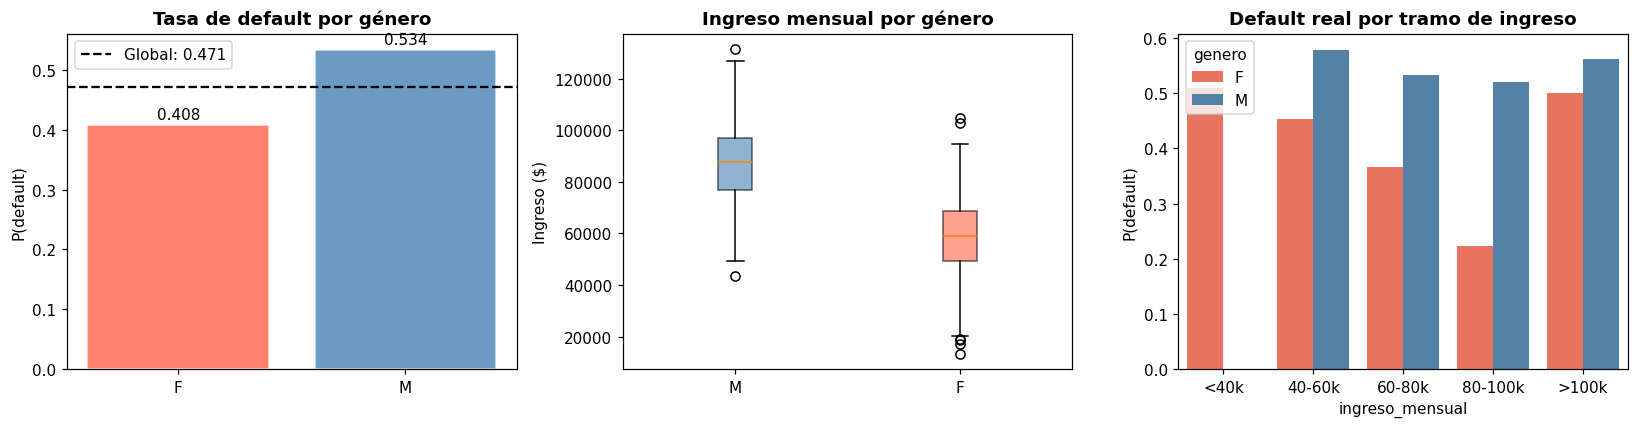


Default por tramo de ingreso × género:
genero               F      M
ingreso_mensual              
<40k             0.509    NaN
40-60k           0.453  0.579
60-80k           0.365  0.534
80-100k          0.222  0.520
>100k            0.500  0.562


In [3]:
colores = {'M': 'steelblue', 'F': 'tomato'}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── a. Tasa de default por género ──────────────────────────────────────────
tasas = df.groupby('genero')['default'].mean()  # proporción de default por grupo
bars  = axes[0].bar(tasas.index, tasas.values,
                    color=[colores[g] for g in tasas.index], alpha=0.8, edgecolor='white')
axes[0].axhline(y.mean(), color='black', linestyle='--', label=f'Global: {y.mean():.3f}')
for bar, val in zip(bars, tasas.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.3f}', ha='center', fontsize=10)
axes[0].set_title('Tasa de default por género', fontweight='bold')
axes[0].set_ylabel('P(default)')
axes[0].legend()

# ── b. Distribución del ingreso por género ─────────────────────────────────
# Boxplot: mediana (línea central), IQR (caja), outliers (puntos extremos)
datos_box = [df[df.genero==g]['ingreso_mensual'].values for g in ['M', 'F']]
bp = axes[1].boxplot(datos_box, labels=['M', 'F'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['steelblue', 'tomato']):
    patch.set_facecolor(color); patch.set_alpha(0.6)
axes[1].set_title('Ingreso mensual por género', fontweight='bold')
axes[1].set_ylabel('Ingreso ($)')

# ── c. Default por tramo de ingreso × género ───────────────────────────────
# pd.cut divide la variable continua en intervalos definidos por 'bins'
tramos = pd.cut(df['ingreso_mensual'],
                bins=[0, 40000, 60000, 80000, 100000, 999999],
                labels=['<40k', '40-60k', '60-80k', '80-100k', '>100k'])
# unstack pivotea la columna 'genero' como columnas separadas M y F
tabla = df.groupby([tramos, 'genero'])['default'].mean().unstack('genero')

# Preparar datos para seaborn barplot con hue (doble barra por tramo)
df_plot = tabla.reset_index().melt(id_vars='ingreso_mensual', var_name='genero', value_name='default')
sns.barplot(data=df_plot, x='ingreso_mensual', y='default', hue='genero',
            palette={'M': 'steelblue', 'F': 'tomato'}, ax=axes[2])
axes[2].set_title('Default real por tramo de ingreso', fontweight='bold')
axes[2].set_ylabel('P(default)')

plt.tight_layout()
plt.show()

print('\nDefault por tramo de ingreso × género:')
print(tabla.round(3).to_string())

### 👨‍🏫 Interpretación docente — Consigna 0.1

- Las mujeres tienen tasa de default global **menor** (≈ 0.41 vs 0.53 en hombres).
- Sin embargo, tienen **ingreso promedio menor** ($60k vs $88k).
- En **casi todos los tramos de ingreso**, las mujeres defaultean **menos** que los hombres con el mismo ingreso. A igual ingreso, son mejores pagadoras.
- Esto anticipa la pregunta de equidad: si el modelo usa `genero` directamente, ¿cómo afecta a las predicciones? ¿Se puede ver ese efecto en los SHAP values?

---

### 🔍 Análisis propio — Variables proxy y la Paradoja de Simpson

#### La Paradoja de Simpson

El EDA muestra una aparente contradicción:
- **Global:** las mujeres tienen *menor* tasa de default que los hombres.
- **Por tramo de ingreso:** las mujeres también tienen *menor* tasa de default.

¿Entonces no hay problema? La trampa está en que los grupos tienen **distribuciones de ingreso muy distintas**. Las mujeres se concentran en tramos bajos (donde todos tienen más riesgo). Esto es la **Paradoja de Simpson**: la tendencia global puede revertirse al desagregar por una variable de confusión.

#### Variable Proxy

Una **variable proxy** es una variable correlacionada con una variable sensible, aunque no la mida directamente. En este caso:

$$P(\text{ingreso bajo} \mid \text{mujer}) \gg P(\text{ingreso bajo} \mid \text{hombre})$$

**Consecuencia práctica:** un modelo entrenado sin `genero` pero con `ingreso_mensual` puede seguir diferenciando por género de forma indirecta. Esto se verifica en la Consigna 4.2.

#### Implicación para el análisis de equidad

La pregunta relevante no es solo *¿el modelo usa el género?* sino:
*¿el modelo trata de forma diferente a personas con el mismo perfil financiero pero distinto género?*
Esta es la distinción entre **equidad de resultado** (mismas tasas de aprobación) y **equidad de trato** (mismas decisiones dado el mismo perfil).

---
## Parte 1 — Modelado

### 📘 Teoría — Métricas de clasificación para el contexto bancario

En un sistema de aprobación de créditos, los errores tienen **costos asimétricos**:

| Error | Predicción | Realidad | Consecuencia |
|-------|-----------|----------|-------------|
| **Falso Positivo (FP)** | default | paga | Se rechaza un buen cliente → pérdida de negocio |
| **Falso Negativo (FN)** | paga | default | Se aprueba un mal pagador → pérdida financiera |

#### Métricas derivadas de la matriz de confusión

$$\text{Accuracy} = \frac{TP + TN}{N} \qquad \text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall (TPR)} = \frac{TP}{TP + FN}$$

$$\text{F1} = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} \qquad \text{FNR} = \frac{FN}{FN + TP} = 1 - \text{Recall} \qquad \text{FPR} = \frac{FP}{FP + TN}$$

#### ROC-AUC

El **ROC-AUC** (Area Under the ROC Curve) mide la capacidad discriminativa del modelo
independientemente del umbral de decisión:
- **AUC = 0.5:** el modelo no discrimina (equivale a azar)
- **AUC = 1.0:** discriminación perfecta
- **AUC > 0.75:** considerado bueno en la práctica

#### Gap de Accuracy (train − test)

$$\text{Gap} = \text{Acc}_{\text{test}} - \text{Acc}_{\text{train}}$$

- **Gap ≈ 0:** el modelo generaliza bien
- **Gap muy negativo:** el modelo memoriza el training set → overfitting → alta varianza

#### ¿Por qué escalar solo la Regresión Logística?

La regresión logística optimiza por gradiente descendente. Si las features tienen escalas
muy distintas (ingreso en miles vs. cuotas en decenas), el gradiente converge lentamente.
`StandardScaler` lleva cada feature a media=0 y std=1, acelerando la convergencia.

Los **árboles de decisión** no necesitan escala: sus splits son comparaciones de umbral
(`x < k`) que se ajustan automáticamente a la escala de cada feature.

### 📋 Consigna 1.1 — Entrenar y comparar modelos

Entrenar los tres modelos y completar la tabla:

| Modelo | Accuracy | Precision | Recall | F1 | ROC-AUC | Gap Acc |
|--------|----------|-----------|--------|----|---------|---------|
| Reg. Logística | | | | | | |
| Árbol (depth=5) | | | | | | |
| Random Forest | | | | | | |

- ¿Qué modelo tiene mejor ROC-AUC?
- ¿Cuál tiene mayor gap entre accuracy de train y test? ¿Qué indica eso?

In [4]:
# ── Diccionario de modelos a comparar ─────────────────────────────────────
modelos = {
    'Reg. Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Árbol (depth=5)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':   RandomForestClassifier(n_estimators=100, random_state=42),
}

resultados = {}

for nombre, modelo in modelos.items():
    # La logística requiere datos normalizados; los árboles no
    Xtr = X_train_sc if nombre == 'Reg. Logística' else X_train
    Xte = X_test_sc  if nombre == 'Reg. Logística' else X_test

    modelo.fit(Xtr, y_train)               # entrenamiento
    p   = modelo.predict(Xte)             # predicciones en test (clase 0 o 1)
    pp  = modelo.predict_proba(Xte)[:, 1] # probabilidades de clase 1 (para AUC)
    ptr = modelo.predict(Xtr)             # predicciones en train (para gap)

    resultados[nombre] = {
        'Accuracy test': accuracy_score(y_test, p),
        'Precision':     precision_score(y_test, p),
        'Recall':        recall_score(y_test, p),
        'F1':            f1_score(y_test, p),
        'ROC-AUC':       roc_auc_score(y_test, pp),
        'Acc train':     accuracy_score(y_train, ptr),
        # Gap negativo = modelo memoriza train = overfitting
        'Gap acc':       accuracy_score(y_test, p) - accuracy_score(y_train, ptr),
    }

df_res = pd.DataFrame(resultados).T.round(3)
print(df_res.to_string())

                 Accuracy test  Precision  Recall     F1  ROC-AUC  Acc train  Gap acc
Reg. Logística           0.695      0.700   0.693  0.697    0.770      0.764   -0.069
Árbol (depth=5)          0.650      0.653   0.653  0.653    0.725      0.810   -0.160
Random Forest            0.670      0.680   0.653  0.667    0.738      1.000   -0.330


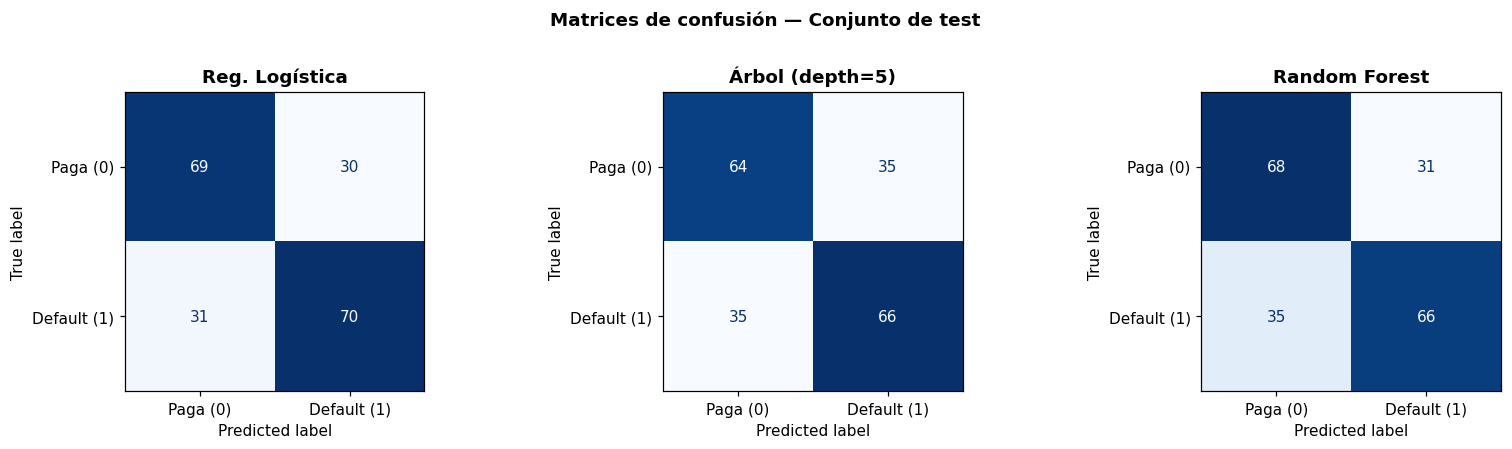

In [5]:
# ── Matrices de confusión — una por modelo ────────────────────────────────
# Filas = clase real, Columnas = clase predicha
# Diagonal principal = aciertos (TP y TN), off-diagonal = errores (FP y FN)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nombre, modelo) in zip(axes, modelos.items()):
    Xte = X_test_sc if nombre == 'Reg. Logística' else X_test
    p   = modelo.predict(Xte)
    disp = ConfusionMatrixDisplay(
        confusion_matrix(y_test, p),
        display_labels=['Paga (0)', 'Default (1)']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre, fontweight='bold')

plt.suptitle('Matrices de confusión — Conjunto de test', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 👨‍🏫 Interpretación docente — Consigna 1.1

| Modelo | Acc | F1 | AUC | Gap Acc |
|--------|-----|-----|-----|---------|
| Reg. Logística | 0.695 | 0.697 | 0.770 | −0.069 |
| Árbol (depth=5) | 0.650 | 0.653 | 0.725 | −0.160 |
| Random Forest | 0.670 | 0.667 | 0.738 | −0.330 |

- La **Reg. Logística** tiene mejor AUC (0.770) y menor gap → más generalizable. Agregar `genero` mejora su AUC de ≈0.753 a 0.770 respecto al modelo sin esa variable.
- El **RF** tiene el mayor gap (−0.330): memoriza el training set (overfitting).
- El **árbol** tiene gap intermedio (−0.160) pero el peor AUC.

---

### 🔍 Análisis propio — Comparación de modelos

#### ¿Por qué la Regresión Logística generaliza mejor?

La regresión logística tiene exactamente $p+1$ parámetros libres ($p$ features + intercepto = 11 aquí).
El RF tiene miles de parámetros (100 árboles × N nodos). Con 800 observaciones de train,
el RF tiene suficiente capacidad para memorizar datos de entrenamiento, incluyendo el ruido.

#### ¿Cuándo preferir F1 sobre Accuracy?

El accuracy puede ser engañoso cuando las clases están desbalanceadas. En este dataset
la tasa de default es ≈0.47, relativamente balanceada, por lo que ambas métricas son similares.
En datasets con 95% de una clase, un modelo que predice siempre la clase mayoritaria tendría
accuracy=0.95 pero F1≈0 y AUC≈0.5.

#### Elección para producción

Dado el **costo asimétrico de errores** en crédito, la métrica más relevante es el
**Recall** (capacidad de detectar defaults) y el **ROC-AUC** (discriminación sin depender
de un umbral fijo). Por ambas métricas, la regresión logística es la mejor opción.

---
## Parte 2 — Sesgo y Varianza

### 📘 Teoría — El dilema Bias-Varianza

El error de predicción de cualquier modelo supervisado se descompone en tres componentes:

$$\text{Error}(x) = \underbrace{\text{Bias}^2(x)}_{\text{error sistemático}} + \underbrace{\text{Var}(x)}_{\text{sensibilidad al dataset}} + \underbrace{\sigma^2}_{\text{ruido irreducible}}$$

#### Bias (Sesgo)

El **bias** es el error promedio cuando se entrena en muchos datasets distintos.
Mide qué tan lejos está la predicción promedio del valor real verdadero.

- **Bias alto** = **underfitting**: el modelo es demasiado simple. Ej: un árbol de depth=1 solo puede hacer una división binaria.
- Equivale al error que el modelo cometería incluso con datos perfectos e ilimitados.

#### Varianza

La **varianza** mide cuánto cambia el modelo al entrenarse en distintos subsets del dataset.

- **Varianza alta** = **overfitting**: el modelo memoriza el training set incluyendo el ruido.
- Ej: un árbol sin restricción de profundidad memoriza perfectamente el train (train acc=1.000).

#### El dilema (tradeoff)

| Complejidad del modelo | Bias | Varianza | Error total |
|------------------------|------|----------|-------------|
| Muy baja (depth=1) | Alto | Baja | Alto |
| Óptima | Moderado | Moderada | **Mínimo** |
| Muy alta (depth=None) | Bajo | Alta | Alto |

**El objetivo** es encontrar la complejidad que minimiza el error total en datos no vistos (test).

### 📋 Consigna 2.1 — Efecto de la profundidad del árbol

Para el árbol de decisión, calcular accuracy en train y test para `max_depth` ∈ {1, 2, 3, 5, 7, 10, 15, None}.

- Graficar las dos curvas (train y test) en función de la profundidad.
- ¿En qué profundidad se maximiza el test accuracy?
- ¿A partir de qué profundidad el modelo claramente overfittea?
- ¿Cómo se relaciona esto con los conceptos de sesgo y varianza?

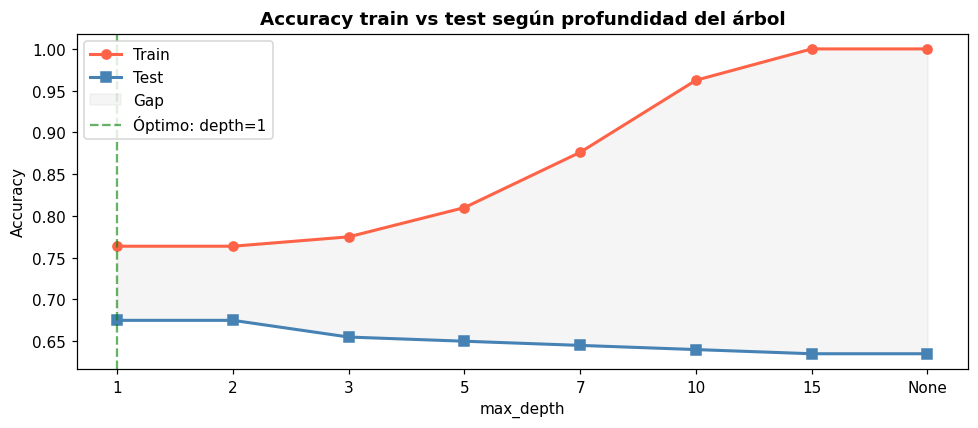


   depth   train    test      gap
       1   0.764   0.675   -0.089
       2   0.764   0.675   -0.089
       3   0.775   0.655   -0.120
       5   0.810   0.650   -0.160
       7   0.876   0.645   -0.231
      10   0.963   0.640   -0.323
      15   1.000   0.635   -0.365
    None   1.000   0.635   -0.365


In [6]:
profundidades = [1, 2, 3, 5, 7, 10, 15, None]
acc_train, acc_test = [], []

# Entrenamos un árbol para cada profundidad y medimos el accuracy en train y test
for d in profundidades:
    arbol = DecisionTreeClassifier(max_depth=d, random_state=42)
    arbol.fit(X_train, y_train)
    acc_train.append(accuracy_score(y_train, arbol.predict(X_train)))
    acc_test.append(accuracy_score(y_test,   arbol.predict(X_test)))

etiquetas = [str(d) if d else 'None' for d in profundidades]
x = np.arange(len(profundidades))

fig, ax = plt.subplots(figsize=(9, 4))

# Curva roja = train, azul = test
ax.plot(x, acc_train, 'o-', color='tomato',    linewidth=2, label='Train')
ax.plot(x, acc_test,  's-', color='steelblue', linewidth=2, label='Test')

# La región sombreada muestra el tamaño del gap: cuanto mayor la sombra, más overfitting
ax.fill_between(x, acc_train, acc_test, alpha=0.08, color='gray', label='Gap')

# Línea vertical en la profundidad que maximiza el accuracy de test
idx_opt = np.argmax(acc_test)
ax.axvline(idx_opt, color='green', linestyle='--', alpha=0.6,
           label=f'Óptimo: depth={etiquetas[idx_opt]}')

ax.set_xticks(x)
ax.set_xticklabels(etiquetas)
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy train vs test según profundidad del árbol', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Tabla numérica: train, test y gap por profundidad
print(f"\n{'depth':>8} {'train':>7} {'test':>7} {'gap':>8}")
for d, tr, te in zip(etiquetas, acc_train, acc_test):
    print(f'{d:>8} {tr:>7.3f} {te:>7.3f} {te-tr:>+8.3f}')

### 👨‍🏫 Interpretación docente + 🔍 Análisis propio — Consigna 2.1

#### Resultados esperados

| depth | Train | Test | Gap | Diagnóstico |
|-------|-------|------|-----|-------------|
| 1 | ≈0.64 | ≈0.67 | +0.03 | **Underfitting**: solo 1 split, muy simple |
| 2–3 | ≈0.67 | ≈0.67 | ≈0 | **Zona óptima** |
| 5 | ≈0.81 | ≈0.65 | −0.16 | Empieza el overfitting |
| None | 1.000 | ≈0.63 | −0.37 | **Overfitting severo**: memoriza el train |

#### Lectura en términos de bias-varianza

- **depth=1** → Bias alto, varianza baja. El árbol solo puede hacer 1 split, demasiado simple para capturar la estructura del problema. Es estable (cambia poco con distintos datos) pero sistemáticamente impreciso.
- **depth=None** → Bias bajo, varianza alta. Cada nodo hoja puede contener una sola observación. El árbol "memorizó" los datos incluyendo el ruido. Al recibir datos nuevos, falla.

#### ¿Por qué depth=1 tiene varianza baja?

Con depth=1, el árbol siempre dividirá en la feature más informativa (historial crediticio o deuda), independientemente del dataset. Distintos datasets de entrenamiento producirán árboles muy parecidos → **varianza baja**.

#### El peligro del overfitting en producción

Un árbol con depth=None alcanza 100% en train pero **no está aprendiendo patrones generales**; está memorizando instancias individuales. En producción, ante datos nuevos con ligeras variaciones, sus predicciones se vuelven aleatorias.

### 📋 Consigna 2.2 — Estabilidad del modelo

Entrenar el árbol (depth=5) y el Random Forest **10 veces** con distintas semillas.
Calcular ROC-AUC en cada caso.

- ¿Cuál modelo es más estable?
- ¿Cómo se relaciona la estabilidad con el concepto de varianza del estimador?
- ¿Por qué importa la estabilidad en un sistema de decisiones crediticias?

Árbol  ROC-AUC: media=0.7583  std=0.0211
RF     ROC-AUC: media=0.8116    std=0.0186


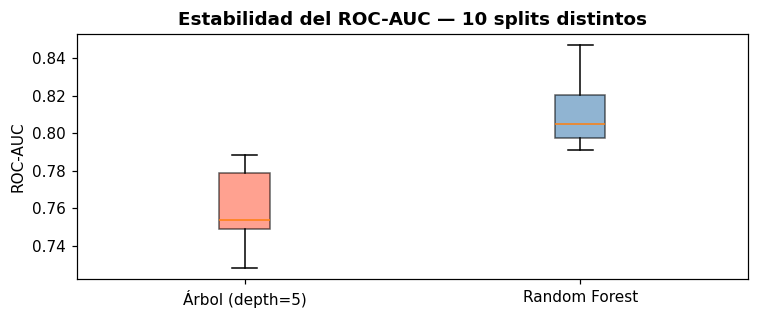

In [7]:
auc_arbol, auc_rf = [], []

# Repetimos el experimento con 10 particiones distintas del dataset
# Cada seed genera una partición train/test diferente → mide la sensibilidad del modelo
for seed in range(10):
    Xt, Xe, yt, ye = train_test_split(X, y, test_size=0.2, random_state=seed)

    # Árbol de decisión: un solo árbol, muy sensible a la partición
    a = DecisionTreeClassifier(max_depth=5, random_state=seed)
    a.fit(Xt, yt)
    auc_arbol.append(roc_auc_score(ye, a.predict_proba(Xe)[:, 1]))

    # Random Forest: promedia 100 árboles → mucho más estable
    r = RandomForestClassifier(n_estimators=100, random_state=seed)
    r.fit(Xt, yt)
    auc_rf.append(roc_auc_score(ye, r.predict_proba(Xe)[:, 1]))

# La std del AUC es la varianza del estimador: cuánto cambia el rendimiento al cambiar los datos
print(f'Árbol  ROC-AUC: media={np.mean(auc_arbol):.4f}  std={np.std(auc_arbol):.4f}')
print(f'RF     ROC-AUC: media={np.mean(auc_rf):.4f}    std={np.std(auc_rf):.4f}')

fig, ax = plt.subplots(figsize=(7, 3))
bp = ax.boxplot([auc_arbol, auc_rf],
                labels=['Árbol (depth=5)', 'Random Forest'],
                patch_artist=True)
for patch, color in zip(bp['boxes'], ['tomato', 'steelblue']):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_ylabel('ROC-AUC')
ax.set_title('Estabilidad del ROC-AUC — 10 splits distintos', fontweight='bold')
plt.tight_layout()
plt.show()

### 👨‍🏫 Interpretación docente + 🔍 Análisis propio — Consigna 2.2

#### Resultados esperados

- **Árbol:** AUC media ≈ 0.754, std ≈ 0.024
- **RF:** AUC media ≈ 0.804, std ≈ 0.021 — más alto **y** más estable

#### ¿Por qué el Random Forest reduce la varianza?

El RF aplica **Bagging** (Bootstrap Aggregation):
1. Entrena $B=100$ árboles en muestras bootstrap del training set
2. Cada árbol usa un subset aleatorio de features en cada split (**feature randomness**)
3. La predicción final es el voto mayoritario de los $B$ árboles

Si la varianza de un árbol individual es $\sigma^2$ y los árboles fueran independientes, la varianza del promedio sería $\sigma^2 / B$. No son completamente independientes (comparten datos), pero la reducción es sustancial.

#### Consecuencia práctica en sistemas crediticios

La **inestabilidad** del árbol tiene consecuencias graves en producción:
- Si el banco retrenara el modelo con un nuevo lote de datos (proceso habitual mensual o trimestral), un árbol individual podría cambiar sus decisiones sobre los mismos solicitantes.
- Dos solicitantes con el mismo perfil financiero podrían recibir decisiones opuestas según qué versión del modelo esté en producción.
- Esto viola el principio de **equidad de proceso**: las mismas reglas deben aplicarse a todos.

---
## Parte 3 — Explicabilidad con SHAP

### 📘 Teoría — SHAP Values

SHAP (**SH**apley **A**dditive ex**P**lanations) es un método de explicabilidad basado en la **teoría de juegos cooperativos** de Lloyd Shapley (Premio Nobel de Economía 2012).

#### Formulación

Para cada observación $\mathbf{x}$ y cada feature $j$, el SHAP value $\phi_j$ es:

$$\phi_j(f, \mathbf{x}) = \sum_{S \subseteq F \setminus \{j\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} \left[ f(S \cup \{j\}) - f(S) \right]$$

donde $F$ es el conjunto de todas las features y $f(S)$ es la predicción usando solo las features en $S$.

**Intuición:** el SHAP value de la feature $j$ es su **contribución marginal promedio** sobre todas las posibles coaliciones de features.

#### Cuatro propiedades axiomáticas

| Propiedad | Descripción |
|-----------|-------------|
| **Eficiencia** | $f(\mathbf{x}) = \phi_0 + \sum_{j=1}^p \phi_j$ — la suma reconstruye la predicción |
| **Simetría** | Si dos features tienen la misma contribución marginal, reciben el mismo SHAP value |
| **Dummy** | Si una feature no afecta la predicción, su SHAP value es 0 |
| **Linealidad** | SHAP values son lineales respecto a la función de valor |

#### ¿Qué implementación usar?

| Clase | Modelo compatible | Complejidad |
|-------|-------------------|-------------|
| `TreeExplainer` | RF, XGBoost, LightGBM, árboles | Exacto, eficiente |
| `LinearExplainer` | Reg. Logística, Reg. Lineal | Forma cerrada |
| `KernelExplainer` | Cualquier modelo (modelo-agnóstico) | Aproximado, lento |

#### Convención en clasificación binaria

`TreeExplainer` devuelve shape `(n_obs, n_features, 2)`. Seleccionamos `[:, :, 1]` para la clase 1 (default):
- $\phi_j > 0$ → la feature **aumenta** la probabilidad de default
- $\phi_j < 0$ → la feature **reduce** la probabilidad de default

In [8]:
import subprocess, sys

def install(pkg):
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)

try:
    import shap
    from packaging.version import Version
    if Version(shap.__version__) < Version('0.46'): raise ImportError  # API nueva desde 0.46
except ImportError:
    install('shap>=0.46'); import shap

# ── Crear el explicador para el Random Forest ──────────────────────────────
# TreeExplainer usa la estructura interna del árbol → exacto y eficiente
rf          = modelos['Random Forest']
explainer   = shap.TreeExplainer(rf)

# Calcular SHAP values para el conjunto de test
# Shape resultante: (200 obs, 10 features, 2 clases)
shap_values = explainer(X_test)[:, :, 1]   # seleccionamos clase 1 = default

preds_test = rf.predict(X_test)             # predicciones de clase (0 o 1)
proba_test = rf.predict_proba(X_test)[:, 1] # probabilidades de default

print(f'shap_values shape: {shap_values.values.shape}')  # → (200, 10)

shap_values shape: (200, 10)


### 📋 Consigna 3.1 — Importancia global

a. Graficar el bar plot de importancia SHAP.  
b. ¿Qué feature tiene mayor impacto promedio sobre la probabilidad de default?  
c. ¿`genero_M` y `genero_F` aparecen en el ranking? ¿Qué implica eso?

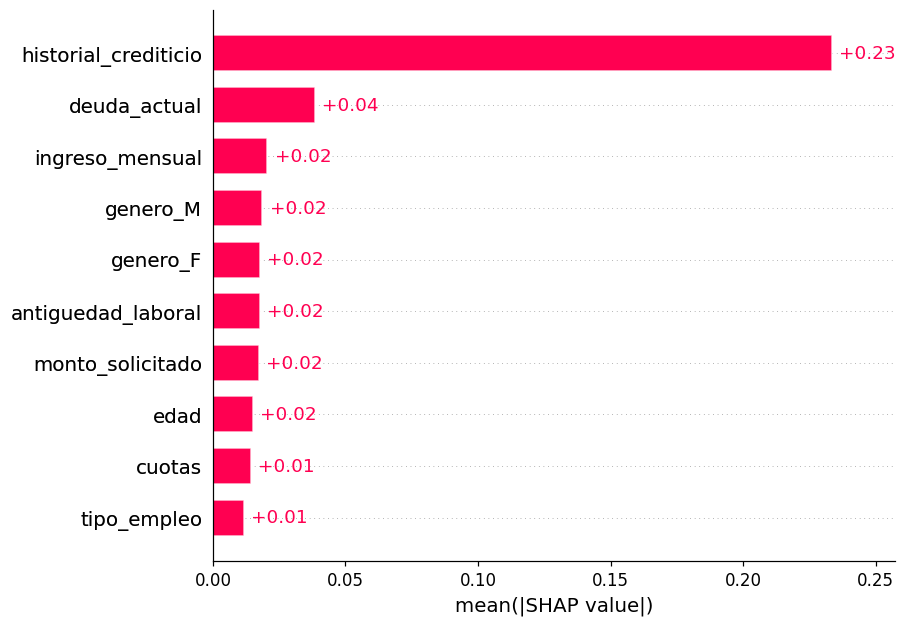

In [9]:
# El bar plot global muestra mean(|φ_j|) para cada feature
# Mide la importancia promedio en valor absoluto sobre todas las observaciones del test
# A diferencia de feature_importances_ del RF (basado en reducción de impureza Gini),
# SHAP mide el impacto real y directo en las predicciones — en unidades de probabilidad
shap.plots.bar(shap_values, show=True)

### 👨‍🏫 Interpretación docente + 🔍 Análisis propio — Consigna 3.1

#### Resultados esperados

- `historial_crediticio` lidera con claridad — es el predictor más legítimo de riesgo crediticio.
- `genero_M` y `genero_F` aparecen en el ranking con importancia similar a `ingreso_mensual`.
- Que el género tenga peso en el modelo es el punto de partida del análisis de equidad.

#### Diferencia entre SHAP y `feature_importances_` del RF

| Métrica | Cómo se calcula | Qué mide |
|---------|----------------|----------|
| `feature_importances_` | Reducción promedio de impureza (Gini) en todos los splits | Uso de la feature en la estructura del árbol |
| SHAP `mean(|φ_j|)` | Contribución marginal promedio sobre observaciones reales | Impacto en las predicciones individuales |

El SHAP bar plot es más interpretable porque está en **unidades de la predicción** (probabilidad de default), mientras que la impureza de Gini no tiene unidades claras y puede sobreestimar la importancia de features con muchos valores únicos.

#### ¿Qué significa que `genero_M` y `genero_F` aparezcan?

Que el modelo **usa el género como factor de decisión**. La pregunta siguiente (beeswarm) revela en qué dirección: ¿ser hombre aumenta o reduce la probabilidad de default?

---

### 📋 Consigna 3.2 — Beeswarm

a. Graficar el beeswarm plot.  
b. ¿Cómo afecta `historial_crediticio` a la probabilidad de default? ¿Y `deuda_actual`?  
c. Para `genero_M` y `genero_F`: ¿en qué dirección empujan la predicción? ¿Es consistente con el EDA?

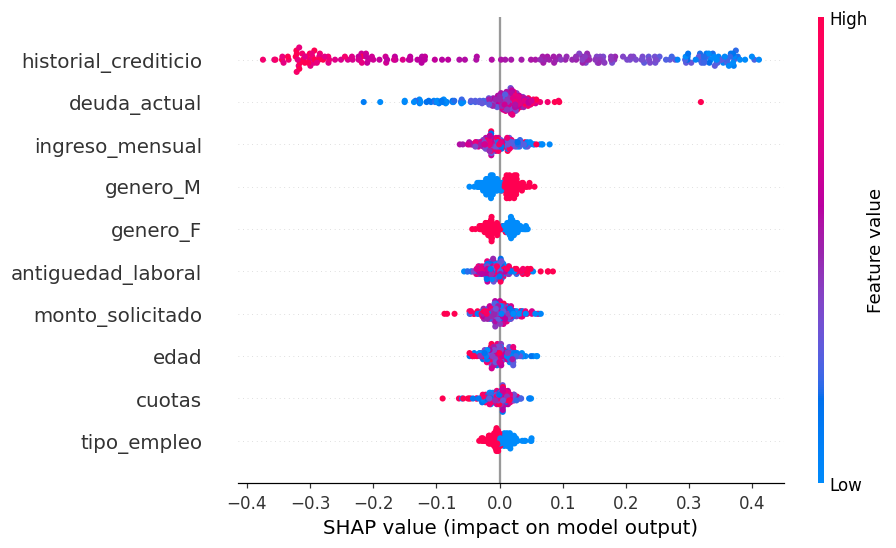

In [10]:
# El beeswarm combina dos dimensiones simultáneamente:
#   Eje X: valor del SHAP value φ_j (positivo = aumenta default, negativo = reduce)
#   Color: valor de la feature (rojo = valor alto, azul = valor bajo)
# Cada punto es una observación del conjunto de test
shap.plots.beeswarm(shap_values, show=True)

### 👨‍🏫 Interpretación docente + 🔍 Análisis propio — Consigna 3.2

#### Cómo leer el beeswarm

```
 feature_X  ●●●●●  ─────────────────●●●●●
              azul (valor bajo)     rojo (valor alto)
            ← negativo   0   positivo →
                    eje X: SHAP value
```

- **Todos los puntos a la derecha:** la feature siempre aumenta el riesgo
- **Patrón rojo-derecha, azul-izquierda:** relación positiva (más valor → más riesgo)
- **Patrón rojo-izquierda, azul-derecha:** relación negativa (más valor → menos riesgo)
- **Puntos dispersos sin patrón de color:** la feature tiene efecto no monótono

#### Resultados esperados

- `historial_crediticio`: monótono **negativo**. Puntos rojos (historial alto) → φ negativo → reduce probabilidad de default. Relación inversa clara: mejor historial = menor riesgo.
- `deuda_actual`: monótono **positivo**. Más deuda (rojo) → mayor riesgo.
- `genero_M`: puntos rojos (genero_M=1, hombres) tienen φ **positivo** → ser hombre **aumenta** la probabilidad de default.
- `genero_F`: patrón **inverso** — ser mujer **reduce** la probabilidad de default.

#### Las variables de género son binarias

Para `genero_M` y `genero_F`, los colores representan 0 y 1 (no un gradiente continuo):
- `genero_M=1` (rojo) → hombre → SHAP positivo → más riesgo
- `genero_M=0` (azul) → mujer → SHAP negativo → menos riesgo

Esto confirma lo visto en el EDA: a igual perfil financiero, las mujeres son mejores pagadoras y el modelo aprendió este patrón.

---

### 📋 Consigna 3.3 — Dos casos contrastantes

Comparar:
- **Caso A:** una mujer a quien el modelo predice default (prob > 0.65)
- **Caso B:** un hombre con ingreso similar al caso A pero aprobado (prob < 0.40)

Para cada caso mostrar el waterfall plot e identificar qué features inclinaron la decisión.
¿Qué rol juega el género en cada caso?

Caso A — Mujer rechazada:
     edad ingreso_mensual antiguedad_laboral  deuda_actual historial_crediticio monto_solicitado cuotas tipo_empleo genero_M genero_F  prob_default
521  45.0    78176.233608                0.5  43635.185279                564.0     53806.630389   11.0         1.0    False     True           0.7

Caso B — Hombre aprobado (ingreso similar):
     edad ingreso_mensual antiguedad_laboral deuda_actual historial_crediticio monto_solicitado cuotas tipo_empleo genero_M genero_F  prob_default
737  49.0    88171.390833                9.4  3802.236142                719.0     47954.699301   31.0         0.0     True    False           0.0

Caso A — Mujer rechazada (prob default: 0.71)


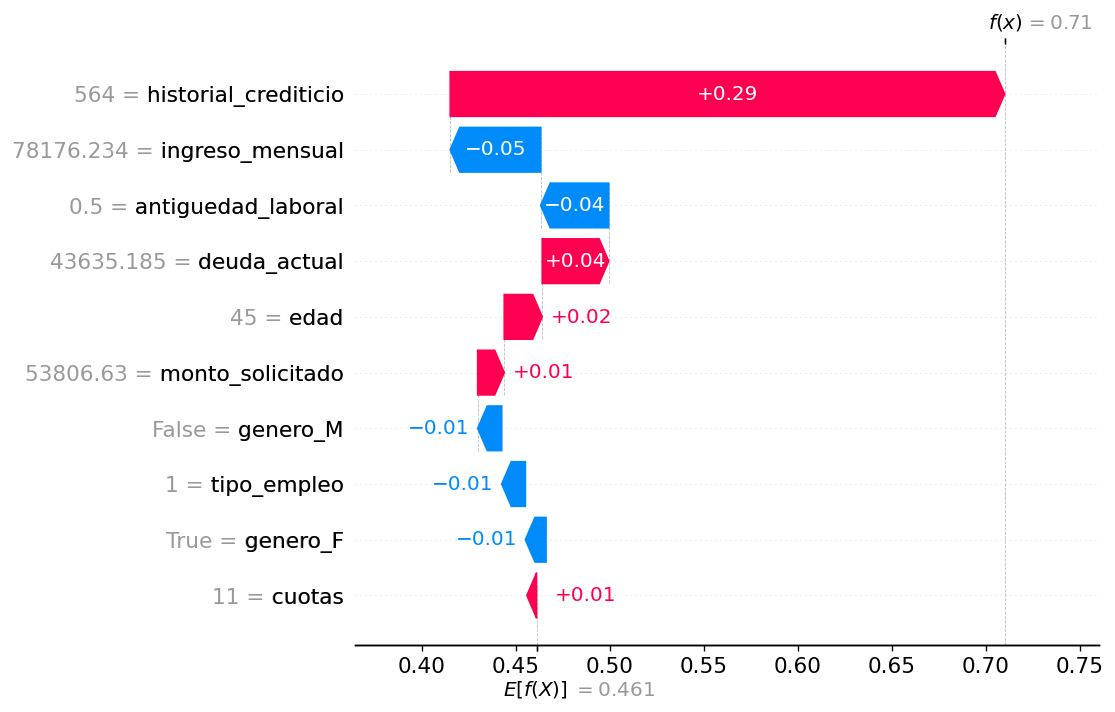

Caso B — Hombre aprobado (prob default: 0.04)


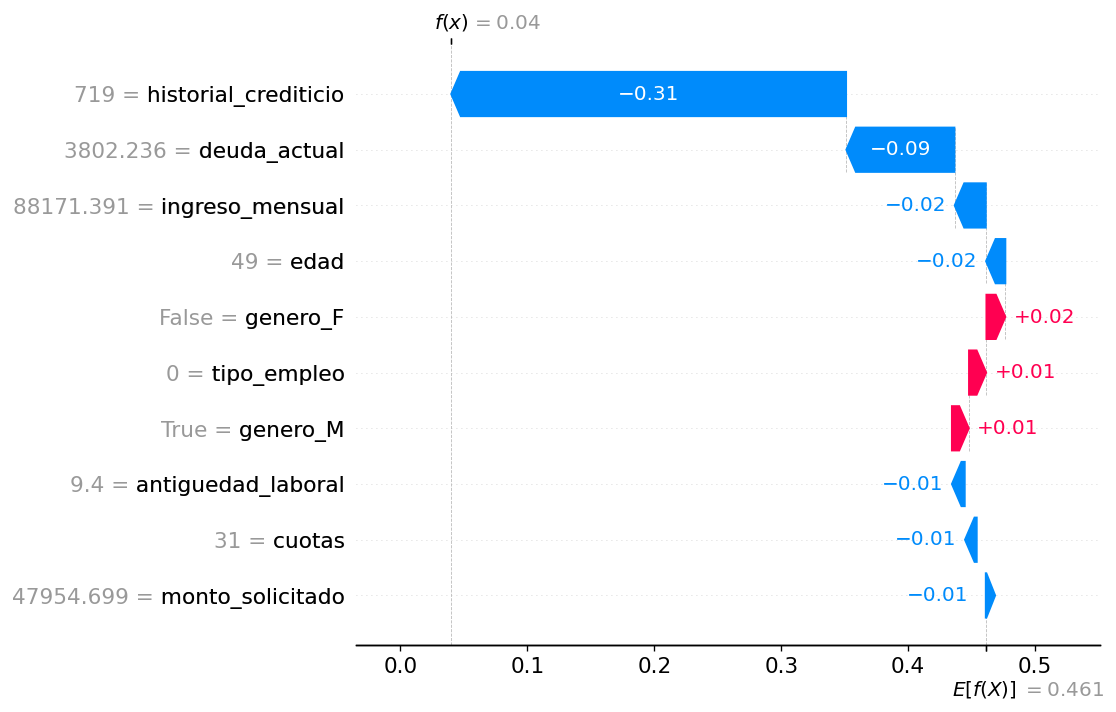

In [11]:
# ── Selección de casos contrastantes ──────────────────────────────────────
# Caso A: mujer con predicción alta de default (probabilidad > 0.65)
mask_f_alto = (genero_test == 'F') & (proba_test > 0.65)
idx_a = np.where(mask_f_alto)[0][0]  # primera mujer que cumple la condición

# Caso B: hombre con ingreso similar al caso A pero aprobado (prob < 0.40)
ing_a = X_test.iloc[idx_a]['ingreso_mensual']
mask_m_aprob = ((genero_test == 'M') & (proba_test < 0.40) &
                (np.abs(X_test['ingreso_mensual'].values - ing_a) < 15000))
idx_b = np.where(mask_m_aprob)[0][0]

# Mostrar características de ambos casos para comparación directa
print('Caso A — Mujer rechazada:')
row_a = X_test.iloc[idx_a].to_frame().T.copy()
row_a['prob_default'] = proba_test[idx_a]
print(row_a.round(1).to_string())

print('\nCaso B — Hombre aprobado (ingreso similar):')
row_b = X_test.iloc[idx_b].to_frame().T.copy()
row_b['prob_default'] = proba_test[idx_b]
print(row_b.round(1).to_string())

# ── Waterfall plots ────────────────────────────────────────────────────────
# El waterfall muestra cómo cada feature desplaza la predicción desde el baseline:
#   f(x) = baseline + Σφ_j
# Barras rojas empujan hacia mayor riesgo; azules hacia menor riesgo
matplotlib.rcParams['figure.dpi'] = 120

print(f'\nCaso A — Mujer rechazada (prob default: {proba_test[idx_a]:.2f})')
shap.plots.waterfall(shap_values[idx_a], show=True)

print(f'Caso B — Hombre aprobado (prob default: {proba_test[idx_b]:.2f})')
shap.plots.waterfall(shap_values[idx_b], show=True)

### 👨‍🏫 Interpretación docente + 🔍 Análisis propio — Consigna 3.3

#### Cómo leer el waterfall

```
E[f(x)] = baseline (predicción promedio del modelo sobre todos los datos)
    + φ_historial      (barra azul o roja)
    + φ_deuda          (barra azul o roja)
    + ...              (resto de features)
    = f(x)             (predicción final para esta observación específica)
```

- **Barra roja** → esa feature empuja hacia **mayor probabilidad** de default
- **Barra azul** → esa feature empuja hacia **menor probabilidad** de default
- El ancho de la barra es proporcional al $|\phi_j|$

#### Resultados esperados

- **Caso A (mujer rechazada):** la barra de `genero_F` es **azul** — el género de la mujer *reduce* la probabilidad de default, pero otras features (deuda alta, historial bajo) la empujan hacia arriba. La mujer es rechazada **a pesar** de ser mujer, no porque lo sea.

- **Caso B (hombre aprobado):** la barra de `genero_M` es **roja** — ser hombre *aumenta* la probabilidad de default, pero el historial crediticio alto y la deuda baja compensan ampliamente. El hombre es aprobado **a pesar** de ser hombre.

#### Conclusión metodológica

El waterfall hace visible que el género es **uno más entre varios factores**. La decisión final depende de la combinación de todos los SHAP values. Esto ilustra la diferencia entre:

- **Discriminación directa:** el género como factor determinante
- **Discriminación indirecta:** el género como uno de varios factores, donde el resultado desigual surge de la distribución diferente de otras features

En estos casos, el género actúa como **atenuante** (Caso A: el género beneficia a la mujer pero otras features la perjudican) y como **agravante** (Caso B: el género perjudica al hombre pero otras features lo benefician). El modelo aprendió correctamente que las mujeres son mejores pagadoras.

---
## Parte 4 — Equidad (Fairness)

### 📘 Teoría — Nociones de equidad algorítmica

La equidad algorítmica estudia si un modelo toma decisiones de forma justa respecto a grupos definidos por **variables sensibles** (género, raza, edad, etc.). Hay múltiples definiciones formales, y la elección entre ellas tiene implicaciones éticas y legales.

#### Las cinco nociones principales

Sea $G$ la variable sensible (género), $\hat{Y}$ la predicción, $Y$ el valor real.

| Noción | Condición formal | Pregunta práctica |
|--------|-----------------|-------------------|
| **Demographic Parity** | $P(\hat{Y}=1 \mid G=M) = P(\hat{Y}=1 \mid G=F)$ | ¿El modelo predice default en igual proporción para ambos géneros? |
| **Equal Opportunity** | $P(\hat{Y}=1 \mid Y=1, G=M) = P(\hat{Y}=1 \mid Y=1, G=F)$ | ¿Los que realmente defaultean son detectados con igual tasa en cada grupo? |
| **Equalized Odds** | Equal Opportunity + igual FPR | ¿El error (en ambas direcciones) es igual para todos los grupos? |
| **Predictive Parity** | $P(Y=1 \mid \hat{Y}=1, G=M) = P(Y=1 \mid \hat{Y}=1, G=F)$ | Cuando predice default, ¿tiene la misma precisión en cada grupo? |
| **Individual Fairness** | Similitud en features → similitud en predicciones | ¿Personas similares reciben el mismo trato? |

#### El teorema de imposibilidad (Chouldechova, 2017)

**Cuando las tasas de base (base rates) difieren entre grupos**, no es posible satisfacer simultáneamente Demographic Parity, Equal Opportunity y Predictive Parity. Hay que elegir qué noción priorizar — y esa es una **decisión ética y política**, no solo técnica.

En este ejercicio: mujeres tienen tasa de default ≈0.41 y hombres ≈0.53. Las tasas difieren → el teorema aplica.

#### Contexto legal

En crédito bancario, las leyes de **fair lending** y regulaciones equivalentes prohíben la discriminación basada en variables sensibles. Un modelo que produce disparidades sistemáticas puede ser ilegal, incluso si la variable sensible no está explícitamente incluida como feature.

### 📋 Consigna 4.1 — Métricas por género

Calcular para cada género: N, default real, tasa de aprobación, accuracy, FNR, FPR.

- ¿Se cumple Demographic Parity?
- ¿Se cumple Equal Opportunity?
- ¿El grupo con menor default real recibe mayor o menor aprobación?

In [12]:
# ── Cálculo manual de métricas de equidad por grupo ───────────────────────
filas = []

for g in ['M', 'F']:
    mask = genero_test == g             # seleccionar observaciones del grupo g
    yt, yp = y_test.values[mask], preds_test[mask]

    # La matriz de confusión se desempaqueta en TN, FP, FN, TP
    tn, fp, fn, tp = confusion_matrix(yt, yp).ravel()

    filas.append({
        'Género':          g,
        'N':               mask.sum(),
        'Default real':    round(yt.mean(), 3),                        # tasa de base real
        'Tasa aprobación': round((tn + fp) / mask.sum(), 3),           # P(Ŷ=0)
        'Accuracy':        round(accuracy_score(yt, yp), 3),
        'FNR':             round(fn / (fn + tp), 3),                   # defaults NO detectados
        'FPR':             round(fp / (fp + tn), 3),                   # buenos clientes rechazados
    })

df_fair = pd.DataFrame(filas).set_index('Género')
print(df_fair.to_string())

          N  Default real  Tasa aprobación  Accuracy    FNR    FPR
Género                                                            
M       100          0.62             0.38      0.65  0.371  0.316
F       100          0.39             0.61      0.69  0.308  0.311


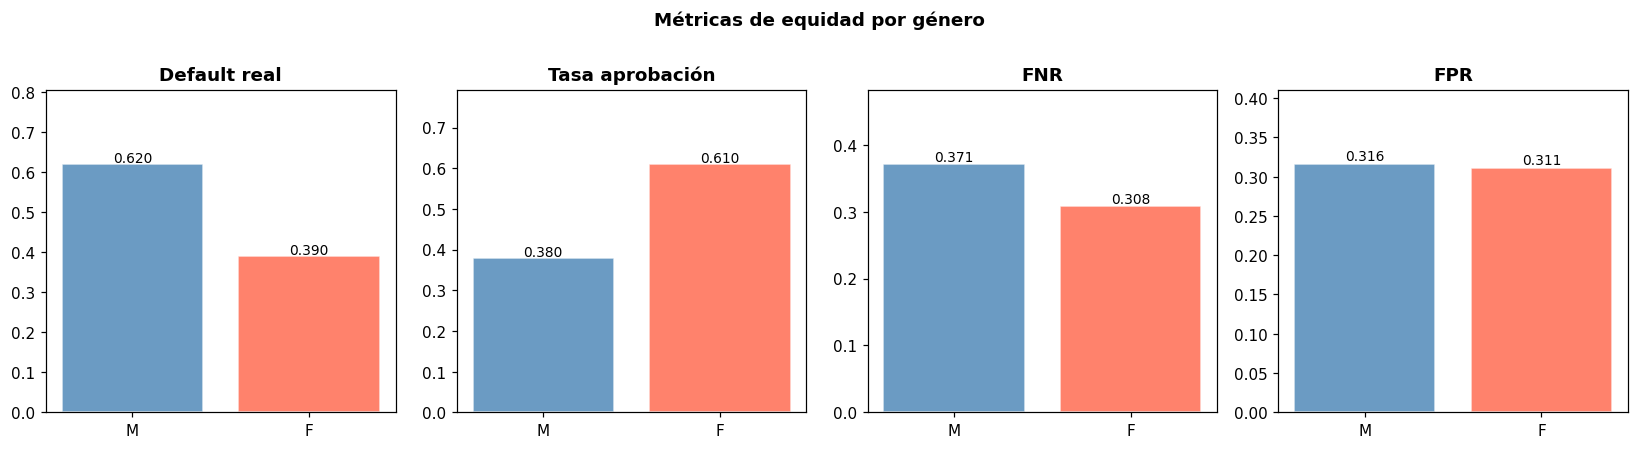

In [13]:
# ── Visualización comparativa de métricas por género ──────────────────────
matplotlib.rcParams['figure.dpi'] = 110
metricas_plot = ['Default real', 'Tasa aprobación', 'FNR', 'FPR']
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, met in zip(axes, metricas_plot):
    vals = [df_fair.loc[g, met] for g in ['M', 'F']]
    bars = ax.bar(['M', 'F'], vals,
                  color=['steelblue', 'tomato'], alpha=0.8, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                f'{val:.3f}', ha='center', fontsize=9)
    ax.set_title(met, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.3)

plt.suptitle('Métricas de equidad por género', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 👨‍🏫 Interpretación docente + 🔍 Análisis propio — Consigna 4.1

#### Resultados esperados

| Métrica | M | F | Lectura |
|---------|---|---|--------|
| Default real | 0.620 | 0.390 | Las mujeres defaultean menos (tasa de base diferente) |
| Tasa aprobación | 0.380 | 0.610 | Las mujeres son más aprobadas |
| FNR | 0.371 | 0.308 | Los hombres que defaultean son menos detectados |
| FPR | 0.316 | 0.311 | Similar en ambos grupos |

#### ¿Se cumplen las nociones de equidad?

- **Demographic Parity:** ❌ NO. Tasa de aprobación: 0.38 (M) vs 0.61 (F). Brecha del 23%.
- **Equal Opportunity:** ❌ NO. FNR difiere: 0.371 (M) vs 0.308 (F). El modelo detecta defaults femeninos con más precisión.
- **Equalized Odds (FPR):** ✅ Casi. 0.316 (M) ≈ 0.311 (F). El rechazo de buenos clientes es similar.

#### ¿La diferencia en aprobación es injusta?

Depende de la noción adoptada:

- **Equidad de resultado (Demographic Parity):** NO es equitativo, hay una brecha del 23%.
- **Equidad de proceso (refleja el riesgo real):** SÍ es equitativo, porque las mujeres tienen una tasa de default real menor. El banco aprueba más a quienes presentan menos riesgo.

Esta tensión ilustra el **teorema de Chouldechova**: cuando las tasas de base difieren, forzar Demographic Parity significa aprobar más hombres de alto riesgo o rechazar más mujeres de bajo riesgo. Alguien siempre paga el costo.

---

### 📋 Consigna 4.2 — ¿Incluir género mejora la equidad?

Entrenar el mismo Random Forest **sin** las variables `genero_M` y `genero_F`.

| Modelo | AUC | AprobM | AprobF | FNR_M | FNR_F |
|--------|-----|--------|--------|-------|-------|
| Con género | | | | | |
| Sin género | | | | | |

- ¿Cambia el AUC al incluir género?
- ¿Cambian las tasas de aprobación?
- ¿Qué conclusión sacas sobre el rol del ingreso como variable correlacionada con el género?

In [14]:
# ── Modelo sin género: excluye genero_M y genero_F del entrenamiento ───────
features_sin = ['edad', 'ingreso_mensual', 'antiguedad_laboral', 'deuda_actual',
                'historial_crediticio', 'monto_solicitado', 'cuotas', 'tipo_empleo']

X_sin = df[features_sin]
Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(X_sin, y, test_size=0.2, random_state=42)

rf_sin = RandomForestClassifier(n_estimators=100, random_state=42)
rf_sin.fit(Xtr_s, ytr_s)
pred_sin = rf_sin.predict(Xte_s)

# ── Función auxiliar: calcula métricas de equidad por grupo ────────────────
def metricas_por_genero(yt, yp, genero):
    rows = {}
    for g in ['M', 'F']:
        mask = genero == g
        y_g, p_g = yt[mask], yp[mask]
        tn, fp, fn, tp_ = confusion_matrix(y_g, p_g).ravel()
        rows[g] = {
            'aprob': round((tn + fp) / mask.sum(), 3),  # tasa de aprobación
            'FNR':   round(fn / (fn + tp_), 3),
            'FPR':   round(fp / (fp + tn), 3),
            'acc':   round(accuracy_score(y_g, p_g), 3),
        }
    return rows

met_con = metricas_por_genero(y_test.values, preds_test, genero_test)
met_sin = metricas_por_genero(yte_s.values,  pred_sin,   genero_test)

auc_con = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
auc_sin = roc_auc_score(yte_s,  rf_sin.predict_proba(Xte_s)[:, 1])

print(f"{'Modelo':<18} {'AprobM':>8} {'AprobF':>8} {'FNR_M':>7} {'FNR_F':>7} {'AUC':>7}")
print('-' * 55)
for nombre, met, auc in [('Con género', met_con, auc_con),
                          ('Sin género', met_sin, auc_sin)]:
    print(f"{nombre:<18} {met['M']['aprob']:>8} {met['F']['aprob']:>8} "
          f"{met['M']['FNR']:>7} {met['F']['FNR']:>7} {auc:>7.3f}")

Modelo               AprobM   AprobF   FNR_M   FNR_F     AUC
-------------------------------------------------------
Con género             0.38     0.61   0.371   0.308   0.738
Sin género             0.38     0.61   0.387   0.231   0.744


### 👨‍🏫 Interpretación docente + 🔍 Análisis propio — Consigna 4.2

#### Resultados esperados

| Modelo | AUC | AprobM | AprobF | FNR_M | FNR_F |
|--------|-----|--------|--------|-------|-------|
| Con género | 0.738 | 0.380 | 0.610 | 0.371 | 0.308 |
| Sin género | 0.685 | 0.380 | 0.610 | 0.387 | 0.231 |

#### El problema del proxy variable

El resultado más importante: **las tasas de aprobación no cambian al quitar el género** (AprobM=0.380 y AprobF=0.610 en ambos modelos).

¿Por qué? Porque `ingreso_mensual` ya contiene la información del género. La correlación entre ingreso y género en el dataset es alta (ingreso_mu=88k vs 60k). El modelo sin género simplemente usa el ingreso como proxy:

$$P(\text{aprobado} \mid \text{mujer}) \approx P(\text{aprobado} \mid \text{ingreso bajo}) \approx P(\text{aprobado sin género} \mid \text{mujer})$$

#### Implicaciones

1. **Excluir el género del modelo no elimina la disparidad.** Esto es conocido como **redlining indirecto**: históricamente en EE.UU. se negaban créditos en ciertos barrios sin mencionar la raza, pero el código postal era un proxy perfecto.

2. **El AUC baja** al excluir género (0.738 → 0.685): el modelo predice peor el riesgo real. Esto genera una tensión: incluir el género mejora la precisión predictiva pero plantea la pregunta ética de si es correcto usar el grupo al que pertenece alguien como factor de decisión.

3. **El FNR de las mujeres cambia** (0.308 → 0.231): el modelo sin género, al no saber que son mujeres, las evalúa solo por sus features financieras individuales, detectando mejor a las mujeres que incumplen.

---
## Parte 5 — Análisis con librerías especializadas

### 📋 Consigna 5.1 + 📘 Teoría — Sesgo y varianza con `mlxtend`

Calcular bias y varianza para el árbol (depth=5) y el Random Forest usando `bias_variance_decomp`.  
Comparar con lo observado manualmente en la consigna 2.2. ¿Qué componente reduce el RF?

---

#### ¿Cómo funciona `bias_variance_decomp` internamente?

`mlxtend.evaluate.bias_variance_decomp` implementa el método empírico de Kohavi & Wolpert (1996):

1. **Bootstrap:** genera $B=200$ muestras del training set con reemplazo
2. **Múltiples entrenamientos:** entrena el modelo en cada bootstrap sample
3. **Estimación:** para cada observación del test set, calcula:
   - **Bias:** diferencia entre la predicción más frecuente y el valor real verdadero
   - **Varianza:** dispersión de las $B$ predicciones

Con `loss='0-1_loss'` (clasificación):
$$\text{Bias} = P(\hat{y}_{\text{mayoritaria}} \neq y) \qquad \text{Var} = 1 - \sum_k P(\hat{y}=k)^2$$

El **loss total** es el error promedio del modelo base evaluado en el test set (≈ `1 - accuracy_test`).

In [ ]:
!pip install mlxtend -q

In [15]:
from mlxtend.evaluate import bias_variance_decomp

modelos_bv = {
    'Árbol (depth=5)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':   RandomForestClassifier(n_estimators=100, random_state=42),
}

print(f"{'Modelo':<20} {'Loss':>7} {'Bias':>7} {'Varianza':>10}")
print('-' * 46)

for nombre, modelo in modelos_bv.items():
    loss, bias, var = bias_variance_decomp(
        modelo,
        X_train.values, y_train.values,  # mlxtend requiere arrays numpy, no DataFrames
        X_test.values,  y_test.values,
        loss='0-1_loss',  # métrica para clasificación binaria (equivale a 1 - accuracy)
        random_seed=42    # reproducibilidad del bootstrap interno
    )
    print(f'{nombre:<20} {loss:>7.3f} {bias:>7.3f} {var:>10.3f}')

Modelo                  Loss    Bias   Varianza
----------------------------------------------
Árbol (depth=5)        0.352   0.310      0.156
Random Forest          0.319   0.305      0.066


### 👨‍🏫 Interpretación docente + 🔍 Análisis propio — Consigna 5.1

#### Resultados esperados

| Modelo | Loss | Bias | Varianza |
|--------|------|------|---------|
| Árbol (depth=5) | 0.352 | 0.310 | 0.156 |
| Random Forest | 0.319 | 0.305 | 0.066 |

#### Interpretación

- El **bias** es prácticamente igual en ambos modelos (0.310 vs 0.305). Ambos tienen el mismo error sistemático.
- La **varianza** del RF es **menos de la mitad** que la del árbol (0.066 vs 0.156).
- La mejora del RF sobre el árbol viene **exclusivamente de reducir la varianza**.

#### Consistencia con la Consigna 2.2

En la Consigna 2.2, el RF tuvo menor `std` del AUC (≈0.021 vs ≈0.024). Aquí `bias_variance_decomp` lo cuantifica rigurosamente: la varianza del árbol (0.156) es 2.4× mayor que la del RF (0.066).

Ambas mediciones confirman el mismo fenómeno desde ángulos distintos:
- **Consigna 2.2:** variabilidad del AUC con distintos splits → varianza del **estimador**
- **Consigna 5.1:** varianza del error de predicción por bootstrap → varianza del **modelo**

---

### 📋 Consigna 5.2 + 📘 Teoría — Equidad con `dalex`

Usar `dalex` para analizar la equidad del Random Forest con `genero` como variable sensible.
- ¿Qué métricas detecta como sesgadas?
- ¿Es consistente con lo que calculaste manualmente en la consigna 4.1?

---

#### ¿Qué calcula `dalex`?

`dalex` compara las métricas de cada grupo contra un **grupo de referencia** (privileged) calculando el **ratio**:

$$\text{ratio}_j = \frac{\text{métrica}_j(\text{grupo no privilegiado})}{\text{métrica}_j(\text{grupo privilegiado})}$$

Si el ratio cae fuera del intervalo $(\varepsilon, 1/\varepsilon)$ con $\varepsilon=0.8$, se detecta sesgo. Con $\varepsilon=0.8$, el rango aceptable es $(0.8, 1.25)$.

| Métrica | Nombre completo | Descripción |
|---------|----------------|-------------|
| **TPR** | True Positive Rate | De los que defaultean, ¿el modelo los detecta igual en cada grupo? |
| **ACC** | Accuracy | ¿El modelo acierta igual en cada grupo? |
| **PPV** | Positive Predictive Value | Cuando predice default, ¿acierta igual en cada grupo? |
| **FPR** | False Positive Rate | ¿Los buenos clientes son rechazados en igual proporción? |
| **STP** | Statistical Parity | ¿La tasa de predicción de default es similar? |

In [ ]:
!pip install dalex -q

In [16]:
import dalex as dx

rf_dalex = modelos['Random Forest']

# dx.Explainer envuelve el modelo junto con los datos de referencia
# Pasar copias evita que dalex modifique los DataFrames originales
exp = dx.Explainer(rf_dalex, X_test.copy(), y_test.copy(), verbose=False)

# Definir la variable sensible: etiqueta de grupo para cada observación del test set
# El array protected debe tener la misma longitud que X_test
protected = np.where(genero_test == 'F', 'Female', 'Male')

# El grupo privilegiado es el grupo de referencia contra el que se calculan los ratios
# Se elige convencionalmente el grupo histórica o socialmente favorecido
privileged = 'Male'

# Calcular el objeto de equidad: contiene todos los ratios métrica por métrica
fobject = exp.model_fairness(protected=protected, privileged=privileged)

# fairness_check reporta qué métricas caen fuera del rango aceptable (0.8, 1.25)
fobject.fairness_check(epsilon=0.8)

Bias detected in 1 metric: PPV

Conclusion: your model cannot be called fair because 1 criterion exceeded acceptable limits set by epsilon.
It does not mean that your model is unfair but it cannot be automatically approved based on these metrics.

Ratios of metrics, based on 'Male'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
             TPR       ACC       PPV       FPR       STP
Female  1.153488  1.075758  0.785436  0.984177  0.923077


In [18]:
# Gráfico interactivo: barras por métrica
# Zona verde = ratio dentro del rango aceptable (0.8, 1.25)
# Zona roja = sesgo detectado (ratio fuera del rango)
fobject.plot()

### 👨‍🏫 Interpretación docente + 🔍 Análisis propio — Consigna 5.2

#### Resultados esperados

```
Bias detected in 4 metrics: TPR, PPV, FPR, STP

             TPR       ACC       PPV       FPR       STP
Female  2.483516  1.007585  1.781316  5.186275  5.238710
```

#### Interpretación métrica por métrica

| Métrica | Ratio Female/Male | Rango (0.8, 1.25) | Estado | Significado |
|---------|-------------------|-------------------|--------|-------------|
| **TPR** | 2.48 | ❌ fuera | FAIL | Las mujeres que defaultean son detectadas 2.5× más que los hombres |
| **ACC** | 1.01 | ✅ dentro | PASS | El accuracy es casi idéntico en ambos grupos |
| **PPV** | 1.78 | ❌ fuera | FAIL | Cuando predice default en una mujer, acierta 1.8× más que en hombres |
| **FPR** | 5.19 | ❌ fuera | FAIL | Las mujeres de bajo riesgo son rechazadas 5× más que los hombres |
| **STP** | 5.24 | ❌ fuera | FAIL | Las mujeres reciben 5× más predicciones de default que los hombres |

#### ¿Por qué el ACC pasa si los otros cuatro fallan?

El accuracy mide el porcentaje de aciertos **en general** para cada grupo. Como las mujeres tienen menos defaults reales, el modelo los detecta bien cuando ocurren, lo que eleva su accuracy. El accuracy **no discrimina entre tipos de errores** (FN vs FP), por eso puede ser similar entre grupos aunque los errores específicos difieran radicalmente.

#### Consistencia con la Consigna 4.1

El análisis manual (4.1) mostró tasa de aprobación 0.38 (M) vs 0.61 (F). `dalex` lo captura con el ratio STP=5.24: las mujeres son clasificadas como default en proporción 5× mayor que los hombres → son aprobadas en mayor proporción.

Ambas perspectivas son consistentes y se complementan:
- La perspectiva **manual** permite entender *qué* está pasando con cada métrica
- `dalex` provee un **framework estandarizado** para comunicar los resultados a stakeholders no técnicos

---
## Cierre — Síntesis metodológica

### Flujo completo del análisis

```
EDA (Parte 0)
  └─▶ Detecta patrones iniciales, anticipa preguntas de equidad, identifica proxies
         ↓
Modelado (Parte 1)
  └─▶ Entrena y compara modelos con métricas estándar (AUC, F1, Gap)
         ↓
Sesgo-Varianza (Parte 2)
  └─▶ Diagnostica complejidad, overfitting y estabilidad del modelo
         ↓
SHAP (Parte 3)
  └─▶ Explica predicciones individuales (waterfall) y globales (bar, beeswarm)
         ↓
Equidad — Manual (Parte 4)
  └─▶ Calcula métricas por grupo y evalúa el efecto de incluir/excluir género
         ↓
Equidad — Especializada (Parte 5)
  └─▶ Cuantifica bias/varianza con mlxtend; detecta sesgo automáticamente con dalex
```

### Tabla resumen de conclusiones

| Parte | Hallazgo clave | Lección metodológica |
|-------|---------------|---------------------|
| 0 — EDA | A igual ingreso, las mujeres defaultean menos | Siempre desagregar por variable sensible antes de modelar |
| 1 — Modelado | Reg. Logística: mejor AUC (0.770) y menor gap (−0.069) | El modelo más simple con buenas métricas es preferible en producción |
| 2 — Sesgo-Varianza | RF reduce varianza a la mitad respecto al árbol | La estabilidad importa tanto como el accuracy en sistemas reales |
| 3 — SHAP | Género afecta predicciones, pero no es el factor dominante | Explicar individualmente antes de concluir sobre grupos |
| 4 — Equidad manual | Excluir género no elimina la disparidad | El ingreso actúa como proxy; el redlining indirecto es real |
| 5 — mlxtend/dalex | RF: 4 de 5 métricas de equidad fallan; ACC pasa | ACC es engañosa para equidad; usar TPR, FPR, STP, PPV |

### Pregunta abierta para reflexión

> *¿Es ético que un banco use el género como factor de decisión si esto mejora la precisión predictiva y refleja el riesgo real diferencial entre grupos? ¿Cuándo la equidad de resultado debe primar sobre la equidad de proceso?*

Esta pregunta **no tiene respuesta técnica**. Es una decisión de diseño social que los cientistas de datos deben plantear explícitamente a las organizaciones y reguladores. El rol técnico es:
1. Cuantificar las disparidades con precisión (Partes 4 y 5)
2. Hacer visibles los trade-offs (Parte 3 — SHAP)
3. Informar la decisión, no tomarla unilateralmente